# FlightLab toolbox tour

FlightLab contains the numerical tools and supplied data used in ME 415. This notebook is a **map of the toolbox**, not a homework solution. Use it to find an analysis, understand its inputs and limitations, try a small example, and then carry ordinary Python into your own analysis.

All student-facing quantities use SI units and degrees unless an interface explicitly says otherwise.

In [1]:
import flightlab

print(f"FlightLab {flightlab.__version__}")
print("Topics:", ", ".join(flightlab.TOPICS))

FlightLab 0.6.0
Topics: atmosphere, airfoils, wings, drag, stability, propulsion, performance, loads


## Browse by engineering question

Choose a topic. The panel shows the available analysis types, required inputs, named outputs, important model limits, and starter code from the same registry used by `python -m flightlab`.

In [2]:
from IPython.display import Markdown, clear_output, display

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

def topic_markdown(key):
    item = flightlab.describe(key)
    bullets = lambda values: "\n".join(f"- {value}" for value in values)
    return f"""### {item.title}

**Question:** {item.question}  
**Course use:** {item.homework}

#### Available analyses
{bullets(item.analyses)}

#### Inputs
{bullets(item.inputs)}

#### Named outputs
{bullets(item.outputs)}

#### Model limits
{bullets(item.limits)}

#### Starter code
```python
{item.example}
```
"""

if widgets is None:
    print("Install flightlab[notebook] for the topic picker. Showing all topics instead.\n")
    flightlab.show_tools()
else:
    picker = widgets.Dropdown(
        options=[(item.title, key) for key, item in flightlab.TOPICS.items()],
        value="atmosphere",
        description="Topic:",
        layout=widgets.Layout(width="430px"),
    )
    details = widgets.Output()

    def render_topic(change=None):
        with details:
            clear_output(wait=True)
            display(Markdown(topic_markdown(picker.value)))

    picker.observe(render_topic, names="value")
    render_topic()
    display(picker, details)

Dropdown(description='Topic:', layout=Layout(width='430px'), options=(('Atmosphere and flight condition', 'atm…

Output()

## A transparent first analysis

The controls below call the same `atmos.at`, `State.q`, `State.mach`, and `State.reynolds` methods that appear in homework code. The function remains visible and reusable.

In [3]:
from flightlab import atmos

def flight_condition(altitude=1400.0, true_airspeed=12.0, length=0.25):
    air = atmos.at(altitude)
    print(f"temperature      {air.temperature:9.2f} K")
    print(f"density          {air.density:9.4f} kg/m³")
    print(f"speed of sound    {air.speed_of_sound:9.2f} m/s")
    print(f"dynamic pressure  {air.q(true_airspeed):9.2f} Pa")
    print(f"Mach number       {air.mach(true_airspeed):9.4f}")
    print(f"Reynolds number   {air.reynolds(true_airspeed, length):9.3e}")

if widgets is None:
    flight_condition()
else:
    widgets.interact(
        flight_condition,
        altitude=widgets.FloatSlider(value=1400, min=0, max=12000, step=100, description="Altitude [m]", style={"description_width": "110px"}),
        true_airspeed=widgets.FloatSlider(value=12, min=1, max=280, step=1, description="TAS [m/s]", style={"description_width": "110px"}),
        length=widgets.FloatLogSlider(value=0.25, base=10, min=-1.3, max=1.7, step=0.05, description="Length [m]", style={"description_width": "110px"}),
    )

interactive(children=(FloatSlider(value=1400.0, description='Altitude [m]', max=12000.0, step=100.0, style=Sli…

## From one condition to a design question

FlightLab functions accept NumPy arrays where a direct sweep is physically natural. This example makes the difference between constant true airspeed and constant equivalent airspeed visible.

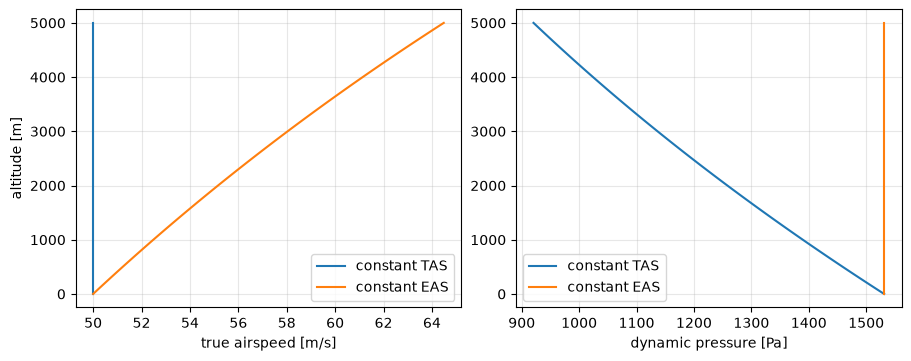

In [6]:
import matplotlib.pyplot as plt
import numpy as np

h = np.linspace(0.0, 5000.0, 101)
V_tas = np.full_like(h, 50.0)
V_eas_case = atmos.eas_to_tas(50.0, h)
q_tas = 0.5 * atmos.density(h) * V_tas**2
q_eas = 0.5 * atmos.density(h) * V_eas_case**2

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)
axes[0].plot(V_tas, h, label="constant TAS")
axes[0].plot(V_eas_case, h, label="constant EAS")
axes[0].set(xlabel="true airspeed [m/s]", ylabel="altitude [m]")
axes[1].plot(q_tas, h, label="constant TAS")
axes[1].plot(q_eas, h, label="constant EAS")
axes[1].set(xlabel="dynamic pressure [Pa]")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

## A case as the bridge to richer interaction

For wing, stability, drag, propulsion, performance, and loads work, a `Case` keeps one aircraft, one flight condition, editable design parameters, and cached analyses together. It is the natural backend for future interactive screens.

In [5]:
from flightlab.case import Case
from flightlab.fleet import RC1

case = Case(RC1, V=12.0, altitude=1400.0)
print(case)
print()
print(case.explain())

# Ordinary assignments define a design variant:
variant = case.copy()
variant.wing.span = 1.4
print("\nBaseline span:", case.panel().span, "m")
print("Variant span: ", variant.panel().span, "m")

<Case RC1  V=12.0 m/s  h=1400.0 m  0 cached>

analysis mode        reads
--------------------------------------------------------------
CL_max               wing, cond, solver
atmosphere           cond
buildup              wing, htail, vtail, cond, solver
derivatives          wing, htail, vtail, mass, cond, solver
mass_properties      wing, htail, vtail, mass, cond, solver
modes                wing, htail, vtail, mass, cond, solver
operating_point      prop, cond
performance          wing, htail, vtail, mass, cond, prop, solver
polar                wing, htail, vtail, cond, solver
section              wing, cond, solver
span_load            wing, mass, cond, solver
trim                 wing, htail, vtail, mass, cond, solver
vn                   wing, mass, cond, solver
wing_aero            wing, htail, vtail, cond, solver

cached now: nothing
<cache 0 memory + 0 disk hits, 0 misses (0% hit rate)>

Baseline span: 1.2 m
Variant span:  1.4 m


## Suggested workflow

1. Start with `flightlab.show_tools()` or the topic picker.
2. Read the model limits before choosing the analysis.
3. Copy the starter code into a new notebook or `.py` file.
4. Replace the example aircraft and conditions with the assigned case.
5. Sweep only the variables needed to answer the engineering question.
6. Interpret the result and state the limitation that controls its credibility.

The next prototype candidates are curated wing-design and propulsion-matching explorers. They should use the same visible-code pattern rather than becoming separate black-box applications.